# PyTorch for Regression / Continous Variable

In [1496]:
import pandas as pd
import numpy as np
import random
import pyarrow as pa
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.optim as optim
# Import

In [1497]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [1498]:
# Load Observation Dataset
# DATA = readRDS(paste0(strap_dir,'Data/Models/RF_bi_model_All_DATA_all_vars_','Trends_Conc_PWS_GW_05to20', '.rds'))
#future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/StRAPs/StRAP4/SSWR.405.1_Future_DW/Data/'
future_dir = 'C:/Users/MPennino/OneDrive - Environmental Protection Agency (EPA)/Projects/OASES/Data/Future_NO3/'


dataset1 = 'Dataset_Conc_Model_SW_COMIDS.csv'
#dataset1 = 'Dataset_Conc_Model_GW_COMIDS.csv'

input_data_ = pd.read_csv(future_dir+dataset1)
input_data_.head(3)

,COMID,mean_conc,PopDen2010Cat,PctCrop2019Cat,precip9120ws,tmean9120cat,BFICat,permcat,RockNCat,N_TW2012Cat,N_Surp_kgsqkm_2017ws,Fe2O3Cat,ElevCat,NHDslope_Pct_Cat
0,12564,0.108571,4.8193,0.00,454.415442,9.029232,65.0000,8.889206,422.7846,3.607679,350.849192,3.6657,1866.1304,15.421640
1,12712,0.780000,42.0676,0.53,660.986854,9.569853,63.9551,7.496483,347.2967,3.707600,648.834773,2.5722,1605.7684,0.819565
2,13230,0.054286,26.6277,0.00,432.323988,9.609029,61.1439,6.617141,385.5680,3.704943,751.514012,3.0452,1716.6487,4.737774


In [1499]:
input_data_.columns

Index(['COMID', 'mean_conc', 'PopDen2010Cat', 'PctCrop2019Cat', 'precip9120ws',
       'tmean9120cat', 'BFICat', 'permcat', 'RockNCat', 'N_TW2012Cat',
       'N_Surp_kgsqkm_2017ws', 'Fe2O3Cat', 'ElevCat', 'NHDslope_Pct_Cat'],
      dtype='str')

In [1500]:
# Remove extra fields from full DF
#input_data_ = input_data_.drop(columns=['RockNCat','N_TW2012Cat','Fe2O3Cat','NHDslope_Pct_Cat']) 


# Test Scatter Plots

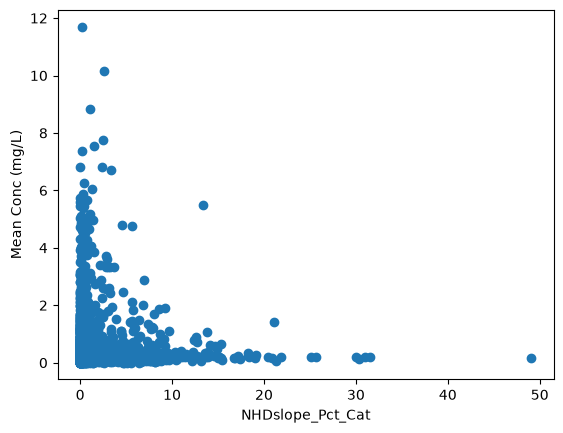

In [1501]:
import matplotlib.pyplot as plt
import numpy as np

#xvar = 'N_Surp_kgsqkm_2017ws'#*
xvar = 'PopDen2010Cat'#*
xvar = 'precip9120ws' # *
#xvar = 'PctCrop2019Cat'
xvar = 'tmean9120cat' #*
xvar = 'BFICat'
xvar = 'permcat'
# xvar = 'RockNCat' #*
xvar = 'N_TW2012Cat' #*
#xvar = 'Fe2O3Cat' #*
#xvar = 'ElevCat' #*
#xvar = 'Fe2O3Cat' #*
xvar = 'NHDslope_Pct_Cat' #*


plt.scatter(input_data_[xvar], input_data_['mean_conc'])
plt.xlabel(xvar)
plt.ylabel("Mean Conc (mg/L)")
plt.show()


In [1502]:
def plots_scatter(DATA):

    fig, axes = plt.subplots(3, 4,figsize=(12, 8))

    # Flattening the axes array makes it easier to loop through
    for i, ax in enumerate(axes.flat, start=1):
        ax.scatter(DATA[:, i-1], DATA['mean_conc'])
        
        # Use set_xlabel and set_ylabel for individual subplot axes
        ax.set_xlabel(f"{DATA[i-1]}")
        ax.set_ylabel("Conc (mg/L)")

    plt.tight_layout()
    plt.show()

In [1503]:
#plots_scatter(input_data_)
input_data_.columns

Index(['COMID', 'mean_conc', 'PopDen2010Cat', 'PctCrop2019Cat', 'precip9120ws',
       'tmean9120cat', 'BFICat', 'permcat', 'RockNCat', 'N_TW2012Cat',
       'N_Surp_kgsqkm_2017ws', 'Fe2O3Cat', 'ElevCat', 'NHDslope_Pct_Cat'],
      dtype='str')

In [1504]:
# Remove extra fields
input_data = input_data_.drop(columns=['COMID']) #,'RockNCat','N_TW2012Cat','Fe2O3Cat','NHDslope_Pct_Cat' 
#input_data = input_data_.drop(columns=['COMID','PctCrop2019Cat','BFICat','permcat' ]) #
#input_data = input_data_[['COMID','mean_conc','N_Surp_kgsqkm_2017ws']] #

input_data.shape

(1848, 13)

In [1505]:
# How many observations have zero conc?
temp = input_data[input_data['mean_conc']==0]
temp.shape, input_data.shape


((48, 13), (1848, 13))

# Create Balanced Dataset (Equal number of rows with different conc ranges)

In [1506]:
pd.Series(input_data['mean_conc']).describe()

count    1848.000000
mean        0.654074
std         1.057952
min         0.000000
25%         0.164286
50%         0.290000
75%         0.632500
max        11.700000
Name: mean_conc, dtype: float64

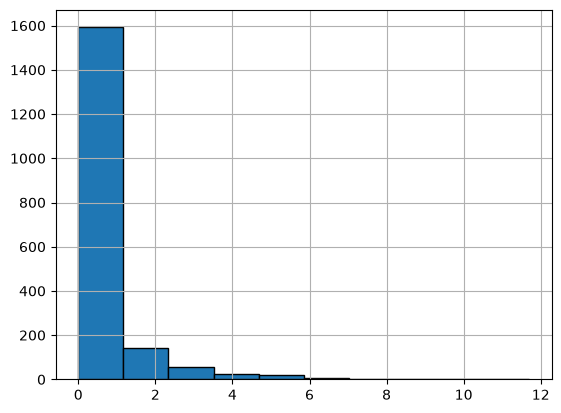

In [1507]:
# Histogram
import matplotlib.pyplot as plt

input_data['mean_conc'].hist(bins=10, edgecolor='black')
plt.show()



In [1508]:
# Calculate numbers in different categories
n0 = len(input_data[input_data['mean_conc']==0])
n0to02 = len(input_data[(input_data['mean_conc'] > 0) & (input_data['mean_conc'] <= 0.2)])
n02to04 = len(input_data[(input_data['mean_conc'] > 0.2) & (input_data['mean_conc'] <= 0.4)])
n04to1 = len(input_data[(input_data['mean_conc'] > 0.4) & (input_data['mean_conc'] <= 1)])
n1to2 = len(input_data[(input_data['mean_conc'] > 1) & (input_data['mean_conc'] <= 2)])
n2to3 = len(input_data[(input_data['mean_conc'] > 2) & (input_data['mean_conc'] <= 3)])
n3to4 = len(input_data[(input_data['mean_conc'] > 3) & (input_data['mean_conc'] <= 4)])
over_n4 = len(input_data[input_data['mean_conc']>4])


print(f"{n0:.2f} = Number = 0")
print(f"{n0to02:.2f} = Number = 0 to 0.2")
print(f"{n02to04:.2f} = Number = 0.2 to 0.4")
print(f"{n04to1:.2f} = Number = 0.4 to 1")

print(f"{n1to2:.2f} = Number = 1 to 2")
print(f"{n2to3:.2f} = Number = 2 to 3")
print(f"{n3to4:.2f} = Number = 3 to 4")
print(f"{over_n4:.2f} = Number = over 4")



48.00 = Number = 0
575.00 = Number = 0 to 0.2
529.00 = Number = 0.2 to 0.4
393.00 = Number = 0.4 to 1
165.00 = Number = 1 to 2
60.00 = Number = 2 to 3
31.00 = Number = 3 to 4
47.00 = Number = over 4


In [1509]:
# Add Group Field to Sampling Concentration Data

# 1. Define the conditions
conditions = [
    (input_data["mean_conc"] == 0),
    (input_data["mean_conc"]  > 0) & (input_data["mean_conc"] <= 0.2),
    (input_data["mean_conc"]  > 0.2) & (input_data["mean_conc"] <= 0.4),
    (input_data["mean_conc"]  > 0.4) & (input_data["mean_conc"] <= 0.6),
    (input_data["mean_conc"]  > 0.6) & (input_data["mean_conc"] <= 0.8),
    (input_data["mean_conc"]  > 0.8) & (input_data["mean_conc"] <= 1),
    (input_data["mean_conc"]  > 1) & (input_data["mean_conc"] <= 2),
    (input_data["mean_conc"] > 2),
]

# 2. Define the corresponding labels
choices = ["n0", "n02", "n04","n06","n08","n1","n2","n2g"]

# 3. Apply using np.select(condlist, choicelist, default)
input_data["Group"] = np.select(conditions, choices, default="Unknown")

In [1510]:
counts = input_data.groupby('Group').size()
print(counts)

Group
n0      48
n02    575
n04    529
n06    213
n08    123
n1      57
n2     165
n2g    138
dtype: int64


### Remove Conc = 0


In [1511]:
input_data = input_data[(input_data['mean_conc'] >0)]


In [1512]:
# Get the min group size
#input_data.groupby('Group')['mean_conc'].min()
#counts = input_data.groupby('Group').size()
#print(counts)
mingroup = input_data.groupby('Group').size().min()
print(mingroup)


57


In [1513]:
# Randomly Sample from different concentration groups
import pandas as pd

# Sample N rows from each group
df_sample = input_data.groupby('Group').sample(n=mingroup, random_state=42)
df_sample.shape


(399, 14)

In [1514]:
counts = df_sample.groupby('Group').size()
print(counts)

Group
n02    57
n04    57
n06    57
n08    57
n1     57
n2     57
n2g    57
dtype: int64


## Transform the concentration data

In [1515]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer

#data_trans = df_sample.copy()

# Remove Group Column
data_trans = df_sample.drop(columns=['Group']) 


# No Transformation
data_trans['mean_conc_scaled'] = data_trans[['mean_conc']]

# Log Transofrm
#data_trans['mean_conc_scaled'] = np.log(1+data_trans[['mean_conc']])

# scaler = MinMaxScaler()
# data_trans['mean_conc_scaled'] = scaler.fit_transform(data_trans[['mean_conc']])

# scaler = RobustScaler()
# data_trans['mean_conc_scaled'] = scaler.fit_transform(data_trans[['mean_conc']])

# scaler = MaxAbsScaler()
# data_trans['mean_conc_scaled'] = scaler.fit_transform(data_trans[['mean_conc']])

# scaler = Normalizer()
# data_trans['mean_conc_scaled'] = scaler.fit_transform(data_trans[['mean_conc']])

# scaler = StandardScaler()
# data_trans['mean_conc_scaled'] = scaler.fit_transform(data_trans['mean_conc'].values.reshape(-1, 1))

# 3. Fit on training data and transform it
#X_train_scaled = scaler.fit_transform(X_train)
#y_train_scaled = scaler.fit_transform(y_train.reshape(-1, 1))

# 4. Transform testing data (using the mean and std learned from X_train)
#X_test_scaled = scaler.transform(X_test) 
#y_test_scaled = scaler.transform(y_test) 

data_prepped = data_trans.copy()

In [1516]:
X_input_data = data_prepped.drop(columns=['mean_conc','mean_conc_scaled']) 
type(X_input_data)

pandas.DataFrame

In [1517]:
data_prepped['mean_conc_scaled'].max(), data_prepped['mean_conc_scaled'].min()

(np.float64(6.82), np.float64(0.0185714285714286))

In [1518]:
type(data_prepped)

pandas.DataFrame

In [1519]:
# Convert to tensors and split into train and test sets
from sklearn.model_selection import train_test_split
X = data_prepped.drop(columns=['mean_conc','mean_conc_scaled']).values
y = data_prepped['mean_conc_scaled'].values

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Make a copy to use later
X_full = X.clone()
y_full = y.clone()

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2,
                                                    random_state=2
)

In [1520]:
# Assess Summary of Conc Data
for col in data_prepped.columns:
    print(f"Mean of {col}: {data_prepped[col].mean()}")

Mean of mean_conc: 1.093024621994547
Mean of PopDen2010Cat: 148.55360776942356
Mean of PctCrop2019Cat: 8.115413533834587
Mean of precip9120ws: 1140.9759730081478
Mean of tmean9120cat: 11.142932055330347
Mean of BFICat: 43.71767894736843
Mean of permcat: 7.801514581555576
Mean of RockNCat: 207.93137568922307
Mean of N_TW2012Cat: 8.110848785757922
Mean of N_Surp_kgsqkm_2017ws: 2647.327052366217
Mean of Fe2O3Cat: 5.873683458646616
Mean of ElevCat: 512.3159669172932
Mean of NHDslope_Pct_Cat: 1.643435268170426
Mean of mean_conc_scaled: 1.093024621994547


In [1521]:
pd.Series(y_test).describe()

count    80.000000
mean      1.080243
std       1.235204
min       0.030000
25%       0.364429
50%       0.677500
75%       1.236161
max       5.688571
dtype: float64

In [1522]:
pd.Series(y_train).describe()

count    319.000000
mean       1.096230
std        1.288266
min        0.018571
25%        0.321833
50%        0.712857
75%        1.100000
max        6.820000
dtype: float64

In [1523]:
nrows = X_train.size()[0]
ncols = X_train.size()[1]
nrows,ncols

(319, 12)

In [ ]:
# 1. Generate synthetic non-normal (skewed) continuous data
# torch.manual_seed(20)
# # X = torch.rand(500, 1) * 10  # Input feature
# # # Create a non-normal target (exponential/skewed noise added to a linear relation)
# # y = 3.5 * X + 2.0 + torch.exponential_rate(torch.ones(500, 1), lam=0.5) 

# # 2. Define a simple Multi-Layer Perceptron (MLP) for non-linear/robust mapping
# class RobustRegressionModel(nn.Module):
#     def __init__(self, input_dim=ncols, hidden_dim=32):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, hidden_dim,bias=True),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, hidden_dim,bias=True),
#             nn.ReLU(),
#             nn.Linear(hidden_dim, 1, bias=True)
#         )
        
#     def forward(self, x):
#         return self.net(x)

# model = RobustRegressionModel()

In [ ]:
# torch.manual_seed(18)
# class ImprovedRegressionModel(nn.Module):
#     def __init__(self, input_dim=ncols, hidden_dim=32, dropout_rate=0.2):
#         super().__init__()
#         self.net = nn.Sequential(
#             # Layer 1
#             nn.Linear(input_dim, hidden_dim, bias=False),
#             nn.BatchNorm1d(hidden_dim, momentum=0.01),
#             nn.LeakyReLU(0.1),
#             nn.Dropout(dropout_rate),
            
#             # Layer 2
#             nn.Linear(hidden_dim, hidden_dim // 2, bias=False),
#             nn.BatchNorm1d(hidden_dim // 2, momentum=0.01),
#             nn.LeakyReLU(0.1),
#             nn.Dropout(dropout_rate),
            
#             # Output Layer (No activation or dropout here for regression)
#             nn.Linear(hidden_dim // 2, 1, bias=False)
#         )
        
#     def forward(self, x):
#         return self.net(x)

# # Example initialization (assuming ncols = 10)
# #ncols = 10
# #model = ImprovedRegressionModel(input_dim=ncols, hidden_dim=32)
# model = ImprovedRegressionModel()

In [1555]:
torch.manual_seed(42)

# 2. Define a simple Multi-Layer Perceptron (MLP) for non-linear/robust mapping
class RobustRegressionModel(nn.Module):
    def __init__(self, input_dim=ncols, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.01),             # Prevents dead neurons
            nn.BatchNorm1d(hidden_dim),     # Stabilizes training
            
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2), 
            nn.Linear(hidden_dim, 1)
        )
        
    def forward(self, x):
        return self.net(x)

model = RobustRegressionModel()

In [1556]:

# 3. Use L1Loss (Mean Absolute Error) to be robust against non-normal/skewed data
criterion = nn.L1Loss() 
optimizer = optim.Adam(model.parameters(), lr=0.0001)
#optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# 4. Training Loop
epochs = 1000
for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    
    # Forward pass
    predictions = model(X_train)
    
    # Compute loss
    loss = criterion(predictions, y_train)
    
    # Backward pass and optimization
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss (MAE): {loss.item():.4f}")

c:\Users\MPennino\anaconda3\envs\future_env\Lib\site-packages\torch\nn\modules\loss.py:133: UserWarning: Using a target size (torch.Size([319])) that is different to the input size (torch.Size([319, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch [100/1000], Loss (MAE): 0.9211
Epoch [200/1000], Loss (MAE): 0.8614
Epoch [300/1000], Loss (MAE): 0.8213
Epoch [400/1000], Loss (MAE): 0.7977
Epoch [500/1000], Loss (MAE): 0.7828
Epoch [600/1000], Loss (MAE): 0.7725
Epoch [700/1000], Loss (MAE): 0.7658
Epoch [800/1000], Loss (MAE): 0.7626
Epoch [900/1000], Loss (MAE): 0.7617
Epoch [1000/1000], Loss (MAE): 0.7613


# Model Evaluation Metrics

In [1557]:
pd.Series(y_test).describe()

count    80.000000
mean      1.080243
std       1.235204
min       0.030000
25%       0.364429
50%       0.677500
75%       1.236161
max       5.688571
dtype: float64

In [1558]:
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze()# X_input_data

y_test[0:10], preds[0:10]

(tensor([0.2529, 0.1643, 0.9800, 0.6500, 2.7233, 0.0300, 0.3520, 0.6050, 0.4643,
         0.6083]),
 tensor([0.6244, 0.7063, 0.7232, 0.6656, 0.6874, 0.7109, 0.7669, 0.6877, 0.6840,
         0.7100]))

In [1559]:
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze()# X_input_data


# Convert to pd dataframe
preds_df = pd.DataFrame(preds.cpu().numpy(), columns=['mean_conc'])

# Transform the data back to its original scale
preds_df_t = scaler.inverse_transform(preds_df)
#preds_df_t = pd.DataFrame(preds_df_t, columns=['mean_conc'])

type(preds_df_t)
#pd.Series(preds_df_t['mean_conc']).describe()


numpy.ndarray

## Adjusted R-Squared

In [1560]:
# Adjusted R Squared based on transfomred data
import torch
from torchmetrics.regression import R2Score
# k = 3 independent features/predictors used in the model
k = ncols 

# Instantiate the metric with the 'adjusted' parameter
r2_metric = R2Score(adjusted=k)

target = y_test
#target = y_test.detach().cpu().numpy()

# Simulated predictions and ground truths
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze()# X_input_data


# Calculate Adjusted R²
adj_r2 = r2_metric(preds, target)
print(f"Adjusted R²: {adj_r2.item()}")

Adjusted R²: -0.30622923374176025


In [1561]:
# function to get r-squared
import numpy as np

def r2(y, pred):
    """Calculates the R-squared (coefficient of determination) score."""
    return 1 - np.var(y - pred) / np.var(y)

In [1562]:
# Get R-Squared based on transformed data
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze()# X_input_data
target = y_test

# Convert tensor to numpy 
obs_np = target.detach().cpu().numpy()
preds_np = preds.detach().cpu().numpy()

r2_result = r2(obs_np,preds_np)
#type(target), type(preds)
print(f"R²: {r2_result.item()}")


R²: 0.004501998424530029


In [1563]:
target[0:10], preds[0:10]

(tensor([0.2529, 0.1643, 0.9800, 0.6500, 2.7233, 0.0300, 0.3520, 0.6050, 0.4643,
         0.6083]),
 tensor([0.6244, 0.7063, 0.7232, 0.6656, 0.6874, 0.7109, 0.7669, 0.6877, 0.6840,
         0.7100]))

In [1564]:
# Get R-Squared based on back-transformed data
target = y_test.detach().cpu().numpy()

# Simulated predictions and ground truths
model.eval()
with torch.no_grad():
    preds = model(X_test).squeeze()# X_input_data
    
# back-transform the data
preds_df = pd.DataFrame(preds.cpu().numpy(), columns=['mean_conc']) # Convert to pd dataframe

# Transform the data back to its original scale
preds_df_t = scaler.inverse_transform(preds_df)
target2 = scaler.inverse_transform(target.reshape(len(target),1))

#target2 = target.reshape(len(target),1)
#type(preds_df_t), type(target2)
#preds_df_t.shape, target2.shape

r2_result = r2(target2,preds_df_t)
print(f"R²: {r2_result.item()}")

R²: 0.0045018792152404785


In [1565]:
# Function for adjusted r-squared

def adj_r2(y, pred,r2,n,k):
    """Calculates the Adjsted R-squared (coefficient of determination) score."""
    return 1 - ((1 - r2)*(n - 1) / (n-k-1))

In [1566]:
n = len(target2)
k = ncols 
r2_result = adj_r2(target2,preds_df_t,r2_result,n,k)
print(f"Adj-R²: {r2_result.item()}")

Adj-R²: -0.17379629611968994


In [1567]:
target2[0:10], preds_df_t[0:10]

(array([[ 1.7383612 ],
        [ 1.135949  ],
        [ 6.683972  ],
        [ 4.4395    ],
        [18.54113   ],
        [ 0.22261429],
        [ 2.4126742 ],
        [ 4.133436  ],
        [ 3.1763775 ],
        [ 4.1561074 ]], dtype=float32),
 array([[4.2652774],
        [4.822435 ],
        [4.9373593],
        [4.5455437],
        [4.6940107],
        [4.8534503],
        [5.2349215],
        [4.695779 ],
        [4.6706247],
        [4.8476367]], dtype=float32))

In [1568]:
target[0:10], preds[0:10]

(array([0.25285715, 0.16428572, 0.98      , 0.65      , 2.7233334 ,
        0.03      , 0.352     , 0.605     , 0.4642857 , 0.60833335],
       dtype=float32),
 tensor([0.6244, 0.7063, 0.7232, 0.6656, 0.6874, 0.7109, 0.7669, 0.6877, 0.6840,
         0.7100]))